# Bonus Activity Q2 - "The Quest" (Netflix Dataset)
## - V tejto aktivite pôjde o vytvorenie EDA pre nami vybraný dataset, jeho spracovanie a namodelovanie vybraných charakteristík pomocou vhodných metód
## - Marek Penzeš, Samuel Petrík - rozdelenie práce 50/50

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [147]:
df = pd.read_csv('datasets/NFLX.csv', parse_dates=['Date'])

### 4.1.1 Základný prehľad dát v datasete

In [148]:
df.shape

(4581, 7)

#### Dataset má 7 stĺpcov/atribútov a 4581 záznamov

In [149]:
print(f"Časové obdobie: {df['Date'].min()} až {df['Date'].max()}")

Časové obdobie: 2002-05-23 00:00:00 až 2020-08-03 00:00:00


In [150]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200
5,2002-05-31,1.078571,1.078571,1.071429,1.076429,1.076429,8464400
6,2002-06-03,1.080000,1.149286,1.076429,1.128571,1.128571,3151400
7,2002-06-04,1.135714,1.140000,1.110714,1.117857,1.117857,3105200
8,2002-06-05,1.110714,1.159286,1.107143,1.147143,1.147143,1531600
9,2002-06-06,1.150000,1.232143,1.148571,1.182143,1.182143,2305800


In [151]:
#Dataset má 3 druhy atribútov - 5krát float, 1 int a 1 datetime pre časovú hodnotu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4581 non-null   datetime64[ns]
 1   Open       4581 non-null   float64       
 2   High       4581 non-null   float64       
 3   Low        4581 non-null   float64       
 4   Close      4581 non-null   float64       
 5   Adj Close  4581 non-null   float64       
 6   Volume     4581 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 250.7 KB


In [152]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,4581,4581.000000,4581.000000,4581.000000,4581.000000,4581.000000,4.581000e+03
mean,2011-06-27 20:17:07.897838592,78.031471,79.285690,76.736079,78.072056,78.072056,1.760516e+07
min,2002-05-23 00:00:00,0.377857,0.410714,0.346429,0.372857,0.372857,2.856000e+05
25%,2006-12-07 00:00:00,3.778571,3.857143,3.685714,3.784286,3.784286,6.908900e+06
50%,2011-06-27 00:00:00,15.392858,15.671429,14.970000,15.324286,15.324286,1.155350e+07
75%,2016-01-14 00:00:00,97.830002,99.529999,96.760002,97.889999,97.889999,2.113440e+07
max,2020-08-03 00:00:00,567.979980,575.369995,520.960022,548.729980,548.729980,3.234140e+08
std,NaN,118.372084,120.276839,116.376768,118.435303,118.435303,1.971130e+07


### 4.1.2 Kontrola "kvality" dát

In [153]:
#v datasete nie sú žiadne duplikáty (neni na to dôvod, keďže čas je stále iný a aj hodnoty na trhu sa menia skoro každú sekundu, i keď niekedy len veľmi málo)
df.duplicated().sum()

np.int64(0)

In [154]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [155]:
#Kontrola či aspoň časové hodnoty sa opakujú
df['Date'].duplicated().sum()

np.int64(0)

In [156]:
#Kontrola či dáta sú zoradené chronologicky
df['Date'].is_monotonic_increasing

True

### 4.1.3 Vizualizácia vývoja cien

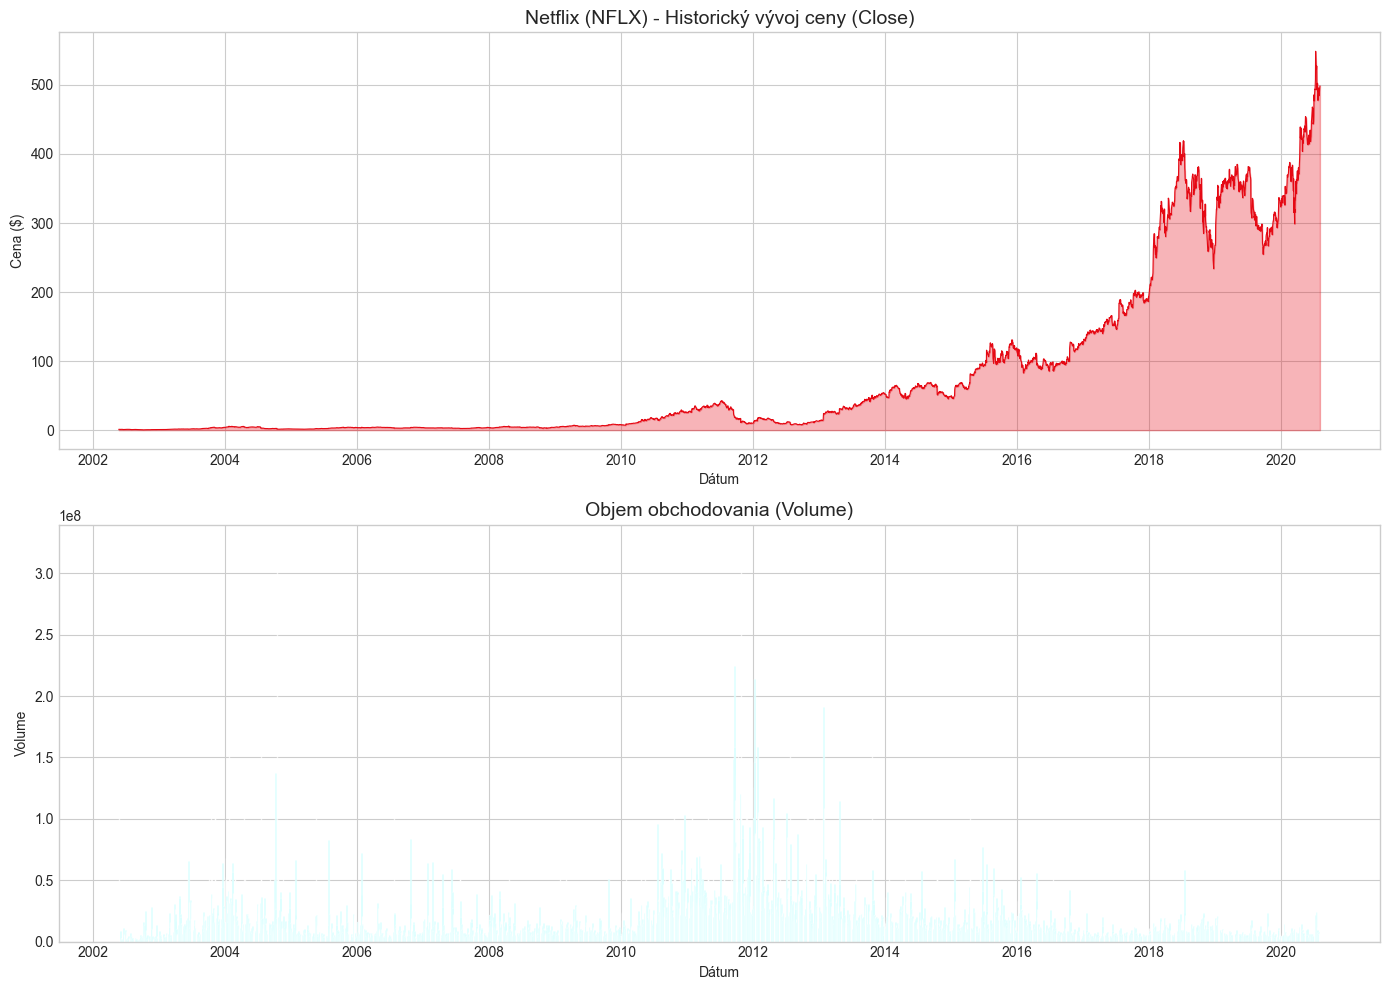

In [157]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#cena Close
axes[0].plot(df['Date'], df['Close'], color='#E50914', linewidth=0.8)
axes[0].set_title('Netflix (NFLX) - Historický vývoj ceny (Close)', fontsize=14)
axes[0].set_xlabel('Dátum')
axes[0].set_ylabel('Cena ($)')
axes[0].fill_between(df['Date'], df['Close'], alpha=0.3, color='#E50914')

#volume
axes[1].bar(df['Date'], df['Volume'], color='aqua', alpha=0.7, width=2)
axes[1].set_title('Objem obchodovania (Volume)', fontsize=14)
axes[1].set_xlabel('Dátum')
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.show()

### 4.1.4 Analýza časových trendov (Bull/Bear)
#### V tejto časti chceme identifikovať obdobia rastu a poklesu cien.
#### Využijeme tzv. "kĺzavý priemer" (Moving Averages) na detekciu týchto trendov:
##### a) Bull Market (rast): vtedy ak kratší MA > dlhší MA
##### b) Bear Market (pokles): vtedy ak kratší MA < dlhší MA

In [158]:
#vytvorím MA pre zaznamenia trendov
df['MA_50'] = df['Close'].rolling(window=50).mean()   #krátkodobý trend
df['MA_200'] = df['Close'].rolling(window=200).mean() #dlhodobý trend

#1 = Bull, 0 = Bear
df['Trend'] = np.where(df['MA_50'] > df['MA_200'], 1, 0)
df['Trend_Label'] = df['Trend'].map({1: 'Bull', 0: 'Bear'})

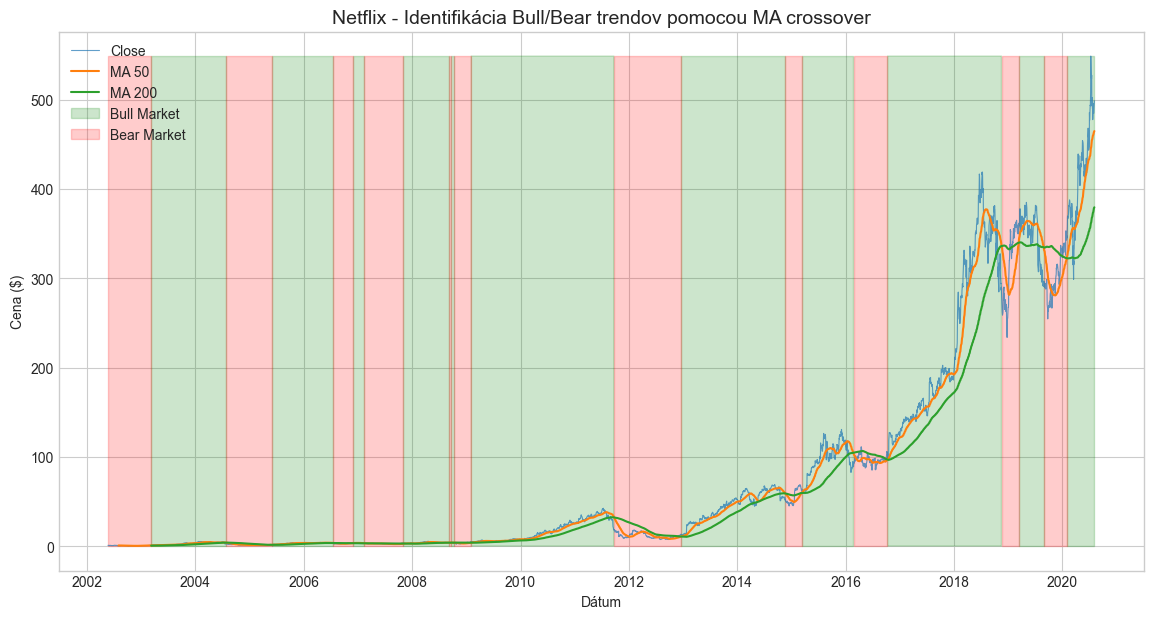

In [159]:
#vizualizácia
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df['Date'], df['Close'], label='Close', alpha=0.7, linewidth=0.8)
ax.plot(df['Date'], df['MA_50'], label='MA 50', linewidth=1.5)
ax.plot(df['Date'], df['MA_200'], label='MA 200', linewidth=1.5)

#zvýraznenie jednotlivých obdobií
bull_periods = df[df['Trend'] == 1]
bear_periods = df[df['Trend'] == 0]

ax.fill_between(df['Date'], df['Close'].min(), df['Close'].max(),
                where=(df['Trend'] == 1), alpha=0.2, color='green', label='Bull Market')
ax.fill_between(df['Date'], df['Close'].min(), df['Close'].max(),
                where=(df['Trend'] == 0), alpha=0.2, color='red', label='Bear Market')

ax.set_title('Netflix - Identifikácia Bull/Bear trendov pomocou MA crossover', fontsize=14)
ax.set_xlabel('Dátum')
ax.set_ylabel('Cena ($)')
ax.legend(loc='upper left')
plt.show()

In [160]:
#štatistika trendov
trend_stats = df.groupby('Trend_Label').agg({
    'Close': ['mean', 'std', 'min', 'max', 'count'], 'Volume': 'mean'}).round(2)

print("Štatistika podľa typu trhu (Bull vs Bear):")
trend_stats

Štatistika podľa typu trhu (Bull vs Bear):


Close                                   Volume
              mean     std   min     max count         mean
Trend_Label                                                
Bear         53.83   99.13  0.37  364.97  1503  18206667.60
Bull         89.91  125.12  1.08  548.73  3078  17311448.05

#### Graf ukazuje vývoj ceny akcií Netflix od roku 2002 do 2020 s vyznačenými obdobiami rastu a poklesu.
#### Vysvetlenie grafu: keď je oranžová krivka (krátkodobý priemer) NAD zelenou krivkou (dlhodobý priemer), ide o rast cien --> Bull Market (zelené obdobie) a naopak, ak je oranžová krivka POD zelenou, ide o pokles cien --> Bear Market (červené obdobie)
#### Zistenia z grafu:
#### - do roku 2012 bola cena nízka (pod 50)
#### - rok 2015 bol asi najviac zlomový bod, lebo od toho momentu (i keď s viacerými prepadmi cien) sa cena viac-menej nezastavila a rastie dodnes
#### - najväčší prepad začal od druhej polky roku 2018 a skončil až v roku 2019, kde v tomto období cena klesla o skoro 100$ (začiatky Covidu v zahraničí, u nás až 2020, odkedy začala cena extrémne rásť kvôli tomu, že veľká časť obyvateľstva ostala doma + iné faktory)

### 4.1.5 Analýza prípadných výnosov
#### Identifikujeme konkrétne časové úseky a ich výnosnosť

In [161]:
#denná % zmena
df['Daily_Return'] = df['Close'].pct_change() * 100

#kumulatívny výnos
df['Cumulative_Return'] = (1 + df['Daily_Return']/100).cumprod()

In [162]:
df['Year'] = df['Date'].dt.year

yearly_performance = df.groupby('Year').agg({'Close': ['first', 'last'],
    'Daily_Return': ['mean', 'std'],'Volume': 'mean'}).round(2)

yearly_performance.columns = ['Open_Price', 'Close_Price', 'Avg_Daily_Return_%', 'Volatility_%', 'Avg_Volume']
yearly_performance['Yearly_Return_%'] = ((yearly_performance['Close_Price'] - yearly_performance['Open_Price']) / yearly_performance['Open_Price'] * 100).round(2)

yearly_performance

,Open_Price,Close_Price,Avg_Daily_Return_%,Volatility_%,Avg_Volume,Yearly_Return_%
Year,,,,,,
2002,1.20,0.79,-0.04,7.01,5081363.64,-34.17
2003,0.82,3.91,0.73,4.36,16888972.22,376.83
2004,3.92,1.76,-0.17,5.03,24017286.11,-55.10
2005,1.70,3.87,0.36,3.12,10636813.89,127.65
2006,3.72,3.69,0.02,2.91,9415647.01,-0.81
2007,3.80,3.80,0.05,2.82,11300373.31,0.00
2008,3.76,4.27,0.14,4.32,11070411.46,13.56
2009,4.27,7.87,0.28,2.86,11523811.11,84.31
2010,7.64,25.10,0.52,3.60,28281111.11,228.53


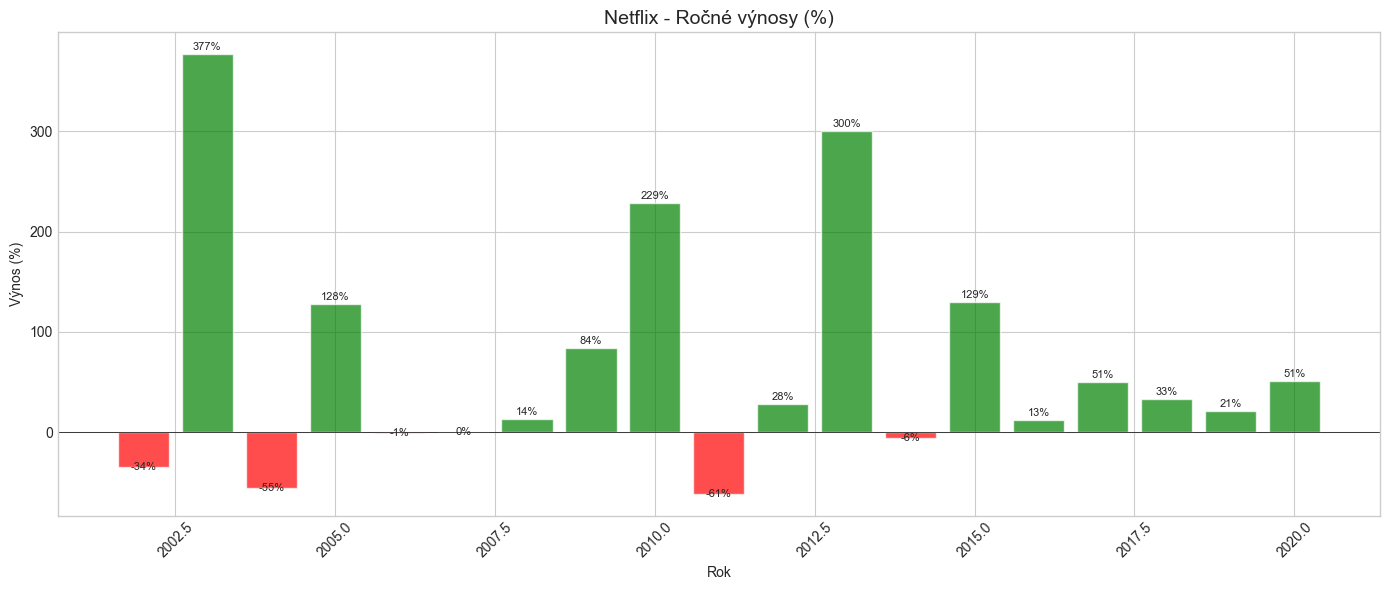

In [163]:
#vizualizácia výnosov
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['green' if x > 0 else 'red' for x in yearly_performance['Yearly_Return_%']]
bars = ax.bar(yearly_performance.index, yearly_performance['Yearly_Return_%'], color=colors, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Netflix - Ročné výnosy (%)', fontsize=14)
ax.set_xlabel('Rok')
ax.set_ylabel('Výnos (%)')

for bar, val in zip(bars, yearly_performance['Yearly_Return_%']):
    ypos = bar.get_height() + (2 if val > 0 else -5)
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.1.6 Identifikácia najväčších prepadov a nárastov

In [164]:
#top 10 najhorších dní (najväčšie denné straty)
worst_days = df.nsmallest(10, 'Daily_Return')[['Date', 'Close', 'Daily_Return', 'Volume']]
worst_days

,Date,Close,Daily_Return,Volume
604,2004-10-15,1.471429,-40.906466,323414000
2374,2011-10-25,11.052857,-34.895656,315541800
540,2004-07-16,3.288571,-28.062516,183836100
2562,2012-07-25,8.611428,-25.015550,173470500
1488,2008-04-22,4.285714,-23.702957,73231900
1050,2006-07-25,2.682857,-20.959607,106622600
3122,2014-10-16,51.671429,-19.369575,92304800
2346,2011-09-15,24.178572,-18.906614,148744400
478,2004-04-16,4.392857,-16.936787,104321700
101,2002-10-16,0.459286,-16.493455,5800200


In [165]:
#10 najlepších dní (najväčšie zisky)
best_days = df.nlargest(10, 'Daily_Return')[['Date', 'Close', 'Daily_Return', 'Volume']]
best_days

,Date,Close,Daily_Return,Volume
2686,2013-01-24,20.980000,42.223509,118805400
97,2002-10-10,0.506429,35.823922,13577200
2747,2013-04-23,30.998571,24.442276,114860900
103,2002-10-18,0.682857,24.155818,24904600
1934,2010-01-28,9.005714,23.680602,77352800
2437,2012-01-26,16.572857,22.064392,158944100
124,2002-11-18,0.778571,19.780154,10061800
102,2002-10-17,0.550000,19.751092,7481600
3627,2016-10-18,118.790001,19.028054,42168200
343,2003-10-02,2.926429,18.719229,73129000


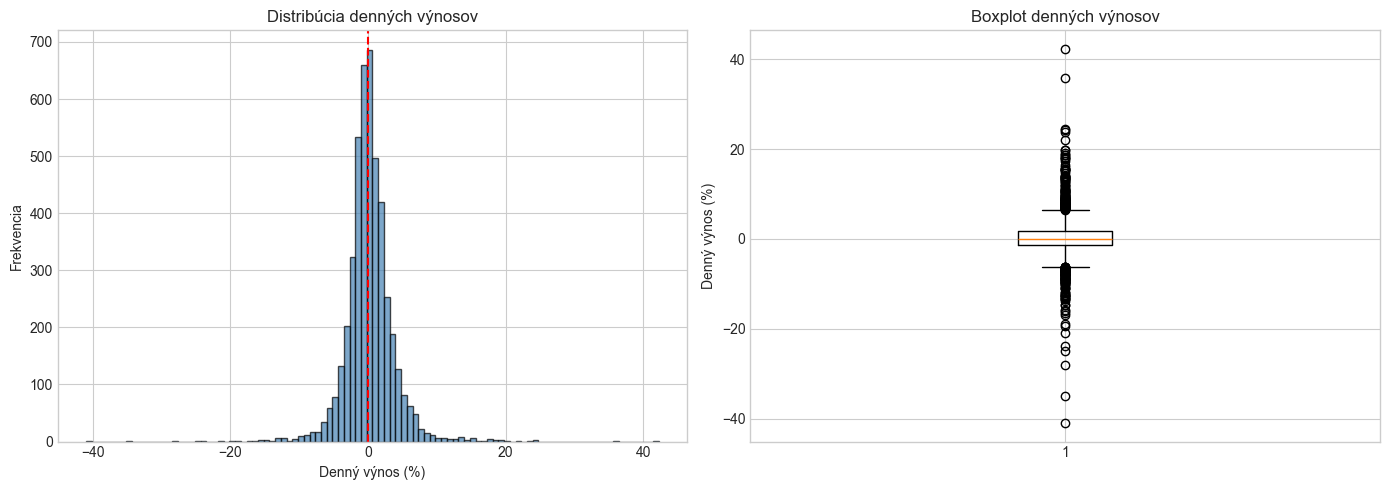

- Priemer: 0.1981%
- Medián: 0.0324%
- Smerodajná odchýlka (volatilita): 3.6335%
- Skewness: 0.3045


In [166]:
#distribúcia denných výnosov
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histogram
axes[0].hist(df['Daily_Return'].dropna(), bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribúcia denných výnosov', fontsize=12)
axes[0].set_xlabel('Denný výnos (%)')
axes[0].set_ylabel('Frekvencia')

#boxplot
axes[1].boxplot(df['Daily_Return'].dropna(), vert=True)
axes[1].set_title('Boxplot denných výnosov', fontsize=12)
axes[1].set_ylabel('Denný výnos (%)')

plt.tight_layout()
plt.show()

print(f"- Priemer: {df['Daily_Return'].mean():.4f}%")
print(f"- Medián: {df['Daily_Return'].median():.4f}%")
print(f"- Smerodajná odchýlka (volatilita): {df['Daily_Return'].std():.4f}%")
print(f"- Skewness: {df['Daily_Return'].skew():.4f}")

### 4.1.7 Prieskum volatility - kľúčový prvok pre pochopenie rizika a správania trhu
#### - väčšia volatilita = väčšie riziko, ale taktiež môže (nemusí) osoba viac zarobiť

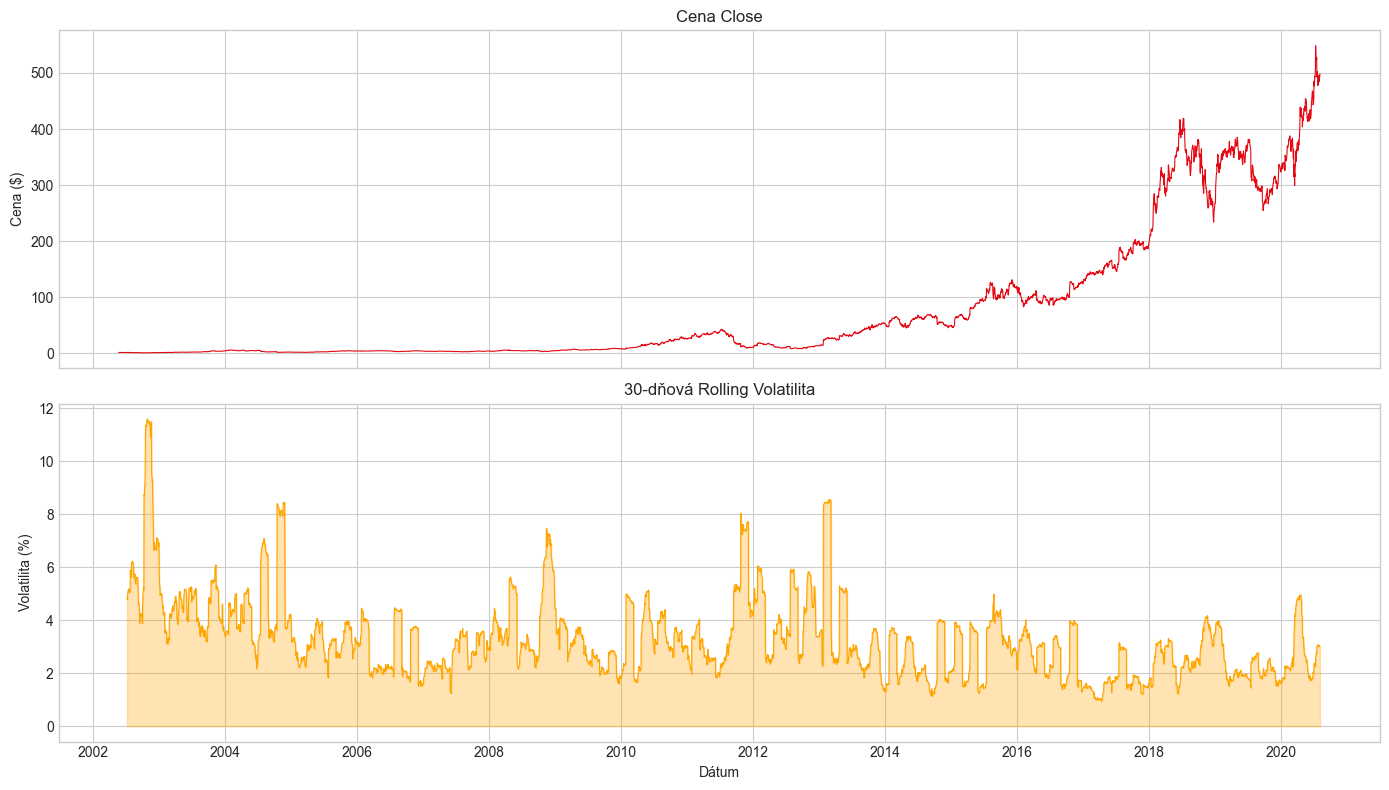

In [167]:
#30-dňová volatilita
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='#E50914', linewidth=0.8)
axes[0].set_title('Cena Close', fontsize=12)
axes[0].set_ylabel('Cena ($)')

axes[1].plot(df['Date'], df['Volatility_30d'], color='orange', linewidth=0.8)
axes[1].fill_between(df['Date'], df['Volatility_30d'], alpha=0.3, color='orange')
axes[1].set_title('30-dňová Rolling Volatilita', fontsize=12)
axes[1].set_ylabel('Volatilita (%)')
axes[1].set_xlabel('Dátum')

plt.tight_layout()
plt.show()

In [168]:
# Porovnanie volatility v Bull vs Bear trhoch
volatility_comparison = df.groupby('Trend_Label')['Volatility_30d'].agg(['mean', 'std', 'max']).round(4)
print("----- Bull vs Bear trhy -----")
volatility_comparison

----- Bull vs Bear trhy -----


,mean,std,max
Trend_Label,,,
Bear,3.8731,1.9287,11.5921
Bull,3.0274,1.1886,8.5584


#### Zistenie: Bear trhy majú typicky vyššiu volatilitu ako Bull trhy, čo je konzistentné s finančnou teóriou - trhy padajú rýchlejšie ako rastú.

### 4.1.8 Feature Engineering pre ML modelovanie
#### - Potrebujeme vytvoriť features, cieľom je predikovať cenu na ďalších 30 dní

In [169]:
df_ml = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

#LAGGED FEATURES (historické hodnoty)
for lag in [1, 7, 14, 30, 60]:
    df_ml[f'Close_Lag_{lag}'] = df_ml['Close'].shift(lag)
    df_ml[f'Volume_Lag_{lag}'] = df_ml['Volume'].shift(lag)

#MA
for window in [5, 10, 20, 50, 100]:
    df_ml[f'MA_{window}'] = df_ml['Close'].rolling(window=window).mean()
    df_ml[f'Volume_MA_{window}'] = df_ml['Volume'].rolling(window=window).mean()

#PRICE CHANGES (zmeny cien)
df_ml['Daily_Return'] = df_ml['Close'].pct_change()
df_ml['Return_7d'] = df_ml['Close'].pct_change(7)
df_ml['Return_14d'] = df_ml['Close'].pct_change(14)
df_ml['Return_30d'] = df_ml['Close'].pct_change(30)

#VOLATILITA
df_ml['Volatility_10d'] = df_ml['Daily_Return'].rolling(window=10).std()
df_ml['Volatility_20d'] = df_ml['Daily_Return'].rolling(window=20).std()
df_ml['Volatility_30d'] = df_ml['Daily_Return'].rolling(window=30).std()

#RSI (Relative Strength Index) - 14 dní
delta = df_ml['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_ml['RSI_14'] = 100 - (100 / (1 + rs))

#Price Range (High - Low)
df_ml['Price_Range'] = df_ml['High'] - df_ml['Low']
df_ml['Price_Range_Pct'] = df_ml['Price_Range'] / df_ml['Close']

#Distance from MA (ako ďaleko je cena od kĺzavého priemeru)
df_ml['Distance_MA_20'] = (df_ml['Close'] - df_ml['MA_20']) / df_ml['MA_20']
df_ml['Distance_MA_50'] = (df_ml['Close'] - df_ml['MA_50']) / df_ml['MA_50']

df_ml['DayOfWeek'] = df_ml['Date'].dt.dayofweek
df_ml['Month'] = df_ml['Date'].dt.month
df_ml['Quarter'] = df_ml['Date'].dt.quarter

df_ml.tail(10)

,Date,Open,High,Low,Close,Volume,Close_Lag_1,Volume_Lag_1,Close_Lag_7,Volume_Lag_7,...,Volatility_20d,Volatility_30d,RSI_14,Price_Range,Price_Range_Pct,Distance_MA_20,Distance_MA_50,DayOfWeek,Month,Quarter
4571,2020-07-21,506.000000,506.220001,488.609985,490.100006,9127200,502.410004,11940300.0,548.729980,21605600.0,...,0.035078,0.030664,58.843710,17.610016,0.035931,-0.002950,0.072699,1,7,3
4572,2020-07-22,492.190002,497.200012,487.200012,489.820007,6954100,490.100006,9127200.0,525.500000,18399000.0,...,0.035053,0.030184,51.244786,10.000000,0.020416,-0.005902,0.069777,2,7,3
4573,2020-07-23,491.130005,491.899994,472.019989,477.579987,7722000,489.820007,6954100.0,524.880005,15083300.0,...,0.035306,0.030656,50.201287,19.880005,0.041627,-0.032680,0.040964,3,7,3
4574,2020-07-24,468.769989,487.170013,467.540009,480.450012,7746200,477.579987,7722000.0,523.260010,10066700.0,...,0.035144,0.030316,45.754422,19.630004,0.040858,-0.028298,0.045298,4,7,3
4575,2020-07-27,484.510010,496.920013,482.309998,495.649994,7863100,480.450012,7746200.0,527.390015,24499000.0,...,0.033619,0.030412,50.724297,14.610015,0.029476,-0.002825,0.075854,0,7,3
4576,2020-07-28,496.019989,497.790009,487.760010,488.510010,5986700,495.649994,7863100.0,492.989990,24991400.0,...,0.033921,0.030554,45.788328,10.029999,0.020532,-0.021252,0.058778,1,7,3
4577,2020-07-29,492.250000,494.920013,484.130005,484.480011,6611800,488.510010,5986700.0,502.410004,11940300.0,...,0.033910,0.030409,43.090348,10.790008,0.022271,-0.032181,0.048594,2,7,3
4578,2020-07-30,480.709991,488.350006,477.510010,485.799988,6608600,484.480011,6611800.0,490.100006,9127200.0,...,0.030436,0.030105,25.572551,10.839996,0.022314,-0.029560,0.049871,3,7,3
4579,2020-07-31,488.290009,494.799988,484.500000,488.880005,5924300,485.799988,6608600.0,489.820007,6954100.0,...,0.030144,0.030109,33.149281,10.299988,0.021069,-0.024575,0.054649,4,7,3
4580,2020-08-03,490.859985,503.089996,490.230011,498.619995,5873100,488.880005,5924300.0,477.579987,7722000.0,...,0.029417,0.030250,38.852096,12.859985,0.025791,-0.005619,0.072774,0,8,3


### 4.1.9 Definícia targetu + čistenie dát
#### - snažíme sa predikovať cenu (Close) o 30 dní dopredu

In [170]:
df_ml['Target_Close_30d'] = df_ml['Close'].shift(-30)

In [171]:
#odstránenie riadkov s NaN (vznikli z "lagov" a rolling operácií)
df_ml_clean = df_ml.dropna()

print(f"Odstránených riadkov: {len(df_ml) - len(df_ml_clean)}")

#nové rozmery datasetu
df_ml_clean.shape

Odstránených riadkov: 129


(4452, 42)

In [172]:
#definícia features a target
exclude_cols = ['Date', 'Target_Close_30d']
feature_cols = [col for col in df_ml_clean.columns if col not in exclude_cols]

X = df_ml_clean[feature_cols]
y = df_ml_clean['Target_Close_30d']

print(f"Features: {feature_cols}")

Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Close_Lag_1', 'Volume_Lag_1', 'Close_Lag_7', 'Volume_Lag_7', 'Close_Lag_14', 'Volume_Lag_14', 'Close_Lag_30', 'Volume_Lag_30', 'Close_Lag_60', 'Volume_Lag_60', 'MA_5', 'Volume_MA_5', 'MA_10', 'Volume_MA_10', 'MA_20', 'Volume_MA_20', 'MA_50', 'Volume_MA_50', 'MA_100', 'Volume_MA_100', 'Daily_Return', 'Return_7d', 'Return_14d', 'Return_30d', 'Volatility_10d', 'Volatility_20d', 'Volatility_30d', 'RSI_14', 'Price_Range', 'Price_Range_Pct', 'Distance_MA_20', 'Distance_MA_50', 'DayOfWeek', 'Month', 'Quarter']


### 4.1.10 Rozdelenie dát (time series split)
#### - Pri časových radoch nepoužívame náhodné rozdelenie, použijeme chronologické rozdelenie = trénovanie na historických dátach, testovanie na novších.

In [173]:
#chronologické rozdelenie: 80% train, 20% test
split_idx = int(len(df_ml_clean) * 0.8)

train_data = df_ml_clean.iloc[:split_idx]
test_data = df_ml_clean.iloc[split_idx:]

X_train = train_data[feature_cols]
y_train = train_data['Target_Close_30d']
X_test = test_data[feature_cols]
y_test = test_data['Target_Close_30d']

print(f"Trénovacia časť: {len(X_train)} vzoriek ({train_data['Date'].min().date()} až {train_data['Date'].max().date()})")
print(f"Testovacia časť: {len(X_test)} vzoriek ({test_data['Date'].min().date()} až {test_data['Date'].max().date()})")

Trénovacia časť: 3561 vzoriek (2002-10-14 až 2016-12-02)
Testovacia časť: 891 vzoriek (2016-12-05 až 2020-06-19)


#### Vytvoríme si aj graf pre lepšie pochopenie rozdelenia

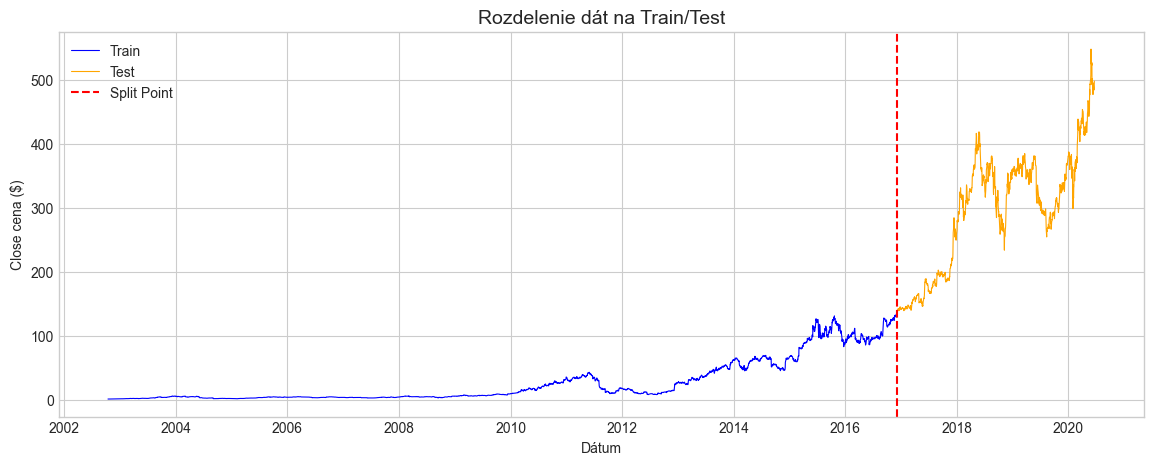

In [174]:
#vizualizácia
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_data['Date'], y_train, label='Train', color='blue', linewidth=0.8)
ax.plot(test_data['Date'], y_test, label='Test', color='orange', linewidth=0.8)
ax.axvline(x=train_data['Date'].iloc[-1], color='red', linestyle='--', label='Split Point')

ax.set_title('Rozdelenie dát na Train/Test', fontsize=14)
ax.set_xlabel('Dátum')
ax.set_ylabel('Close cena ($)')
ax.legend()
plt.show()

### 4.1.11 Škálovanie features a analýza s targetom

In [175]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#konverzia späť na DataFrame pre prehľadnosť
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

#### Vizualizácia korelácie features s našou target premennou

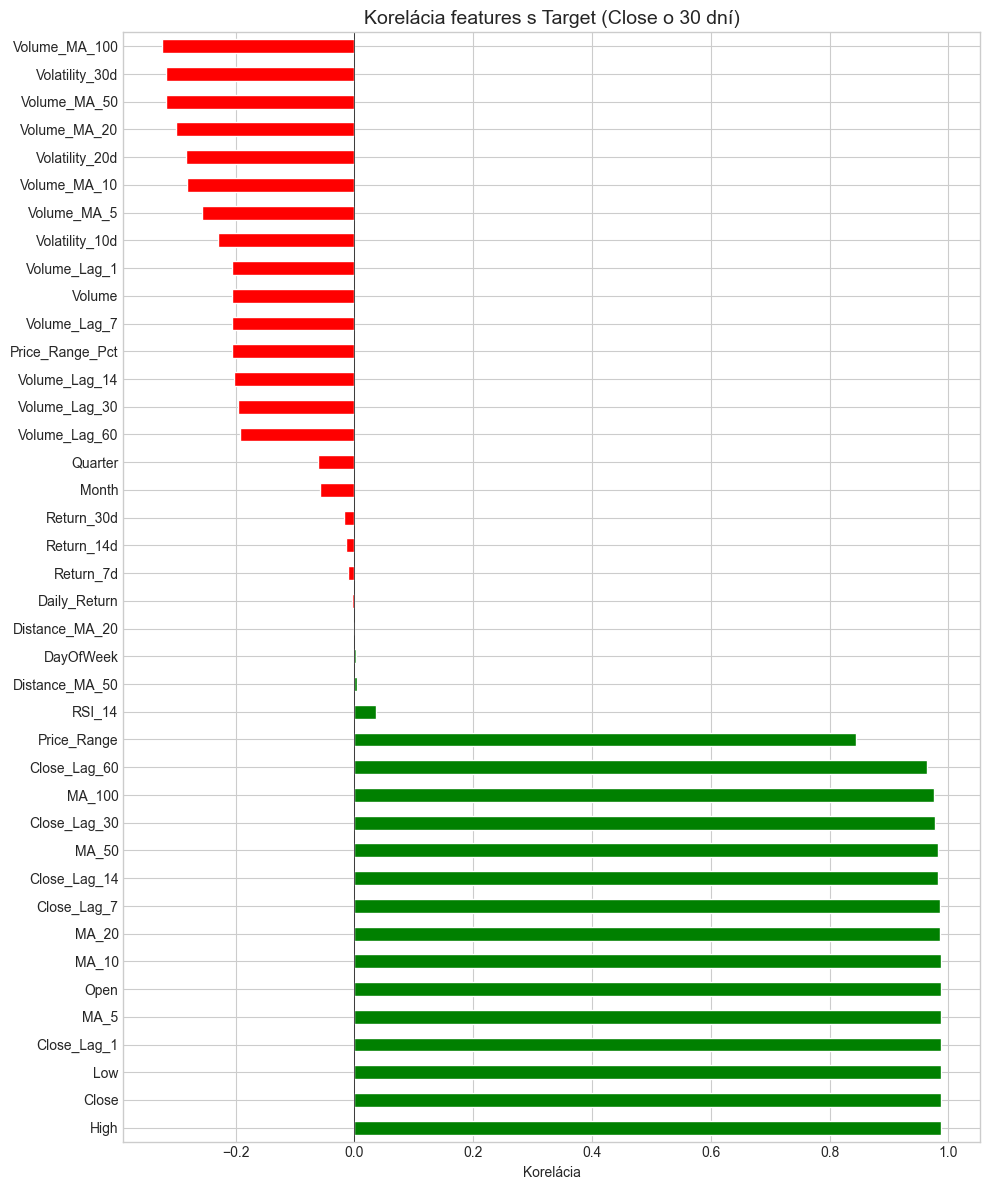

High            0.987747
Close           0.987686
Low             0.987361
Close_Lag_1     0.987346
MA_5            0.987343
Open            0.987319
MA_10           0.986840
MA_20           0.985899
Close_Lag_7     0.985177
Close_Lag_14    0.982985
Name: Target_Close_30d, dtype: float64


In [176]:
correlations = df_ml_clean[feature_cols + ['Target_Close_30d']].corr()['Target_Close_30d'].drop('Target_Close_30d').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
correlations.plot(kind='barh', ax=ax, color=['green' if x > 0 else 'red' for x in correlations])
ax.set_title('Korelácia features s Target (Close o 30 dní)', fontsize=14)
ax.set_xlabel('Korelácia')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()
print(correlations.head(10))

In [177]:
prepared_data = {
    'X_train': X_train,
    'X_test': X_test,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'feature_cols': feature_cols,
    'scaler': scaler,
    'train_dates': train_data['Date'],
    'test_dates': test_data['Date']
}

print(f"- Trénovacia sada: {X_train.shape}")
print(f"- Testovacia sada: {X_test.shape}")
print(f"- Počet features: {len(feature_cols)}")
print(f"- Predikčný horizont: 30 dní")

- Trénovacia sada: (3561, 40)
- Testovacia sada: (891, 40)
- Počet features: 40
- Predikčný horizont: 30 dní


### 4.1.12 Zdôvodnenie výberu ML/DL metód
#### Na základe vypracovanej EDA sme si vybrali metódy z týchto dôvodov:

#### Charakteristiky úlohy:
##### 1. Časový rad - hodnoty majú zavislosť od času
##### 2. Dlhší predikčný horizont (30dní) - vyžaduje robustnejšie modely (napr 7 dní by mohol použiť aj jednoduchšie modely, lebo je tam menšie "okno" na chyby)
##### 3. Vytvorené features - máme až 40 "indikátorov"
##### 4. Dostatok dát

#### Odporúčané metódy:
##### 1) XGBoost
#####   ++ dobrá  na tabulárne dáta, feature importance
#####   - - potrebuje feature engineering
##### 2) Random Forest
#####   ++ robustný, málo náchylný na overfitting
#####   - - pomalší, menej presný jak XGBoost
##### 3) LSTM (Deep Learning)
#####   ++ vhodný pre dlhší horizont
#####   - - potrebuje viac dát, horší na "fine-tuning"
##### 4) Linear Regression - baseline modelov

#### Vybraná metóda:
##### Keďže potrebujem robustný model, čo najrýchlejší, ale zároveň, aby nerobil zbytočné chyby, tak pre náš 30 dňový horizont bude ideálna voľba XGBoost. Mohli by sme zvoliť aj LSTM, ak by sme robili predikciu pre väčšie časové obdobie, ale pre naše obdobie bude stačiť XGBoost.